# Решение: от сырых логинов до антифрод-модели

## Goal

Построить модельную таблицу так, чтобы каждый признак использовал только прошлое относительно текущего события, затем выполнить временной split и обучить baseline.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    PrecisionRecallDisplay,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

DATA_PATH = Path("raw_login_events.csv")
RANDOM_STATE = 42

## Data

`is_fraud` — таргет.  
`fraud_confirmed_at` — момент, когда мошенничество стало известно. Это будущая информация и она исключается из признаков.

In [2]:
raw = pd.read_csv(
    DATA_PATH,
    parse_dates=["event_time", "fraud_confirmed_at"],
)

print("Период:", raw["event_time"].min(), "—", raw["event_time"].max())
print("Строк:", len(raw))
print("Fraud events:", int(raw["is_fraud"].sum()))
print("Fraud rate:", round(raw["is_fraud"].mean(), 4))
raw.head()

Период: 2025-01-01 00:02:05.094998098 — 2025-04-01 00:20:41.523441556
Строк: 18599
Fraud events: 644
Fraud rate: 0.0346


,event_id,event_time,user_id,ip_id,device_id,country,auth_method,login_success,is_fraud,fraud_confirmed_at
0,2450,2025-01-01 00:02:05.094998098,u_0073,ip_u_0073_1,dev_u_0073_0,BY,password,1,0,NaT
1,18401,2025-01-01 00:19:28.652462376,u_0274,ato_ip_018401,ato_dev_018401,RU,password,1,1,2025-01-03 22:19:28.652462376
2,7073,2025-01-01 00:35:33.634319983,u_0211,newip_007073,dev_u_0211_0,KZ,app,1,0,NaT
3,3031,2025-01-01 00:39:14.468897333,u_0091,public_ip_010,dev_u_0091_0,RU,password,1,0,NaT
4,3550,2025-01-01 00:39:52.573033947,u_0106,ip_u_0106_1,dev_u_0106_0,RU,password,1,0,NaT


In [3]:
assert raw["event_id"].is_unique
assert raw["event_time"].notna().all()
assert set(raw["is_fraud"].unique()) <= {0, 1}
assert raw.loc[raw["is_fraud"].eq(1), "fraud_confirmed_at"].notna().all()

raw.groupby("is_fraud")[
    ["login_success"]
].mean().rename(index={0: "legit", 1: "fraud"})

,login_success
is_fraud,
legit,0.931440
fraud,0.630435


## Steps — leakage-safe feature engineering

В каждой функции текущая строка добавляется в историю **после** вычисления признака. Поэтому событие не считает само себя и не видит будущее.

In [4]:

from collections import defaultdict, deque, Counter

def past_count(
    frame,
    group_col,
    window,
    condition_col=None,
    condition_value=None,
):
    """
    Number of PREVIOUS events in [event_time - window, event_time).

    The current event is appended only after its feature value is calculated.
    That ordering is what prevents target-time leakage.
    """
    queues = defaultdict(deque)
    running_condition_count = defaultdict(int)
    result = np.zeros(len(frame), dtype=np.int32)

    for row_number, row in enumerate(frame.itertuples(index=False)):
        event_time = row.event_time
        group_value = getattr(row, group_col)
        queue = queues[group_value]
        cutoff = event_time - window

        while queue and queue[0][0] < cutoff:
            _, old_condition_flag = queue.popleft()
            running_condition_count[group_value] -= old_condition_flag

        if condition_col is None:
            result[row_number] = len(queue)
            condition_flag = 1
        else:
            current_value = getattr(row, condition_col)
            condition_flag = int(current_value == condition_value)
            result[row_number] = running_condition_count[group_value]

        queue.append((event_time, condition_flag))
        running_condition_count[group_value] += condition_flag

    return result


def past_unique(frame, group_col, value_col, window):
    """
    Number of distinct value_col values seen for group_col strictly before
    the current event and inside the selected time window.
    """
    queues = defaultdict(deque)
    counters = defaultdict(Counter)
    result = np.zeros(len(frame), dtype=np.int32)

    for row_number, row in enumerate(frame.itertuples(index=False)):
        event_time = row.event_time
        group_value = getattr(row, group_col)
        current_value = getattr(row, value_col)

        queue = queues[group_value]
        counter = counters[group_value]
        cutoff = event_time - window

        while queue and queue[0][0] < cutoff:
            _, expired_value = queue.popleft()
            counter[expired_value] -= 1
            if counter[expired_value] == 0:
                del counter[expired_value]

        result[row_number] = len(counter)

        queue.append((event_time, current_value))
        counter[current_value] += 1

    return result


def seen_before(frame, group_col, value_col):
    """Whether the group has ever seen this value before the current event."""
    seen_values = defaultdict(set)
    result = np.zeros(len(frame), dtype=np.int8)

    for row_number, row in enumerate(frame.itertuples(index=False)):
        group_value = getattr(row, group_col)
        current_value = getattr(row, value_col)

        result[row_number] = int(
            current_value in seen_values[group_value]
        )
        seen_values[group_value].add(current_value)

    return result


def seconds_since_previous(frame, group_col, cap_seconds=30 * 86400):
    """Seconds since the previous event for the group, capped at 30 days."""
    last_event_time = {}
    result = np.full(len(frame), cap_seconds, dtype=np.float64)

    for row_number, row in enumerate(frame.itertuples(index=False)):
        event_time = row.event_time
        group_value = getattr(row, group_col)

        if group_value in last_event_time:
            delta = (event_time - last_event_time[group_value]).total_seconds()
            result[row_number] = min(delta, cap_seconds)

        last_event_time[group_value] = event_time

    return result


def build_features(raw_frame):
    frame = (
        raw_frame
        .sort_values(["event_time", "event_id"])
        .reset_index(drop=True)
        .copy()
    )

    # Current-event features available at the scoring moment.
    frame["hour"] = frame["event_time"].dt.hour
    frame["is_night"] = frame["hour"].between(0, 5).astype(int)

    # User velocity and history.
    frame["user_events_1h"] = past_count(
        frame, "user_id", pd.Timedelta(hours=1)
    )
    frame["user_events_24h"] = past_count(
        frame, "user_id", pd.Timedelta(days=1)
    )
    frame["user_failed_24h"] = past_count(
        frame,
        "user_id",
        pd.Timedelta(days=1),
        condition_col="login_success",
        condition_value=0,
    )
    frame["user_unique_ips_7d"] = past_unique(
        frame,
        "user_id",
        "ip_id",
        pd.Timedelta(days=7),
    )

    # IP/device graph and velocity features.
    frame["ip_events_1h"] = past_count(
        frame, "ip_id", pd.Timedelta(hours=1)
    )
    frame["ip_unique_users_1h"] = past_unique(
        frame,
        "ip_id",
        "user_id",
        pd.Timedelta(hours=1),
    )
    frame["device_unique_users_24h"] = past_unique(
        frame,
        "device_id",
        "user_id",
        pd.Timedelta(days=1),
    )

    # Familiarity features.
    frame["seen_device_before"] = seen_before(
        frame, "user_id", "device_id"
    )
    frame["seen_ip_before"] = seen_before(
        frame, "user_id", "ip_id"
    )
    frame["seen_country_before"] = seen_before(
        frame, "user_id", "country"
    )
    frame["seconds_since_prev_user_event"] = seconds_since_previous(
        frame, "user_id"
    )

    return frame


In [5]:
model_frame = build_features(raw)

selected_columns = [
    "event_time",
    "user_id",
    "ip_id",
    "device_id",
    "is_fraud",
    "user_events_24h",
    "ip_unique_users_1h",
    "seen_device_before",
]
model_frame[selected_columns].head(10)

,event_time,user_id,ip_id,device_id,is_fraud,user_events_24h,ip_unique_users_1h,seen_device_before
0,2025-01-01 00:02:05.094998098,u_0073,ip_u_0073_1,dev_u_0073_0,0,0,0,0
1,2025-01-01 00:19:28.652462376,u_0274,ato_ip_018401,ato_dev_018401,1,0,0,0
2,2025-01-01 00:35:33.634319983,u_0211,newip_007073,dev_u_0211_0,0,0,0,0
3,2025-01-01 00:39:14.468897333,u_0091,public_ip_010,dev_u_0091_0,0,0,0,0
4,2025-01-01 00:39:52.573033947,u_0106,ip_u_0106_1,dev_u_0106_0,0,0,0,0
5,2025-01-01 00:44:33.633132587,u_0284,public_ip_017,ato_dev_018404,1,0,0,0
6,2025-01-01 00:58:52.255480259,u_0081,newip_002686,newdev_002686,0,0,0,0
7,2025-01-01 01:00:26.876785997,u_0002,ip_u_0002_1,dev_u_0002_1,0,0,0,0
8,2025-01-01 01:07:00.712916114,u_0067,ip_u_0067_0,dev_u_0067_0,0,0,0,0
9,2025-01-01 01:08:48.932745763,u_0447,public_ip_024,dev_u_0447_1,0,0,0,0


## Checks

Проверим один временной признак вручную.

In [6]:
row_number = 5000
event = model_frame.iloc[row_number]

manual_history = model_frame[
    (model_frame["user_id"] == event["user_id"])
    & (model_frame["event_time"] < event["event_time"])
    & (
        model_frame["event_time"]
        >= event["event_time"] - pd.Timedelta(days=1)
    )
]

print("Event time:", event["event_time"])
print("User:", event["user_id"])
print("Feature user_events_24h:", event["user_events_24h"])
print("Manual count:", len(manual_history))

assert event["user_events_24h"] == len(manual_history)

Event time: 2025-01-25 01:11:43.610204568
User: u_0215
Feature user_events_24h: 0
Manual count: 0


In [7]:
comparison = (
    model_frame
    .groupby("is_fraud")[
        [
            "ip_unique_users_1h",
            "device_unique_users_24h",
            "seen_device_before",
            "seen_ip_before",
        ]
    ]
    .mean()
    .rename(index={0: "legit", 1: "fraud"})
)
comparison

,ip_unique_users_1h,device_unique_users_24h,seen_device_before,seen_ip_before
is_fraud,,,,
legit,0.449680,0.212977,0.837427,0.592091
fraud,2.035714,2.281056,0.147516,0.152174


## Time split

- train: события до 20 февраля;
- validation: 20 февраля — 9 марта;
- test: события начиная с 10 марта.

Порог выбирается только на validation. Test используется один раз для финальной проверки.

In [8]:
TRAIN_END = pd.Timestamp("2025-02-20")
VALID_END = pd.Timestamp("2025-03-10")

train = model_frame[model_frame["event_time"] < TRAIN_END].copy()
valid = model_frame[
    (model_frame["event_time"] >= TRAIN_END)
    & (model_frame["event_time"] < VALID_END)
].copy()
test = model_frame[model_frame["event_time"] >= VALID_END].copy()

split_summary = pd.DataFrame(
    {
        "rows": [len(train), len(valid), len(test)],
        "fraud_events": [
            int(train["is_fraud"].sum()),
            int(valid["is_fraud"].sum()),
            int(test["is_fraud"].sum()),
        ],
        "fraud_rate": [
            train["is_fraud"].mean(),
            valid["is_fraud"].mean(),
            test["is_fraud"].mean(),
        ],
    },
    index=["train", "valid", "test"],
)
split_summary

,rows,fraud_events,fraud_rate
train,10437,344,0.032960
valid,3477,110,0.031636
test,4685,190,0.040555


## Baseline model

Логистическая регрессия полезна как первый baseline: она быстрая, понятная и позволяет проверить весь pipeline до перехода к бустингу.

In [9]:
numeric_features = [
    "hour",
    "is_night",
    "login_success",
    "user_events_1h",
    "user_events_24h",
    "user_failed_24h",
    "user_unique_ips_7d",
    "ip_events_1h",
    "ip_unique_users_1h",
    "device_unique_users_24h",
    "seen_device_before",
    "seen_ip_before",
    "seen_country_before",
    "seconds_since_prev_user_event",
]
categorical_features = ["auth_method", "country"]
feature_columns = numeric_features + categorical_features

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ),
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

model.fit(train[feature_columns], train["is_fraud"])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

## Validation ranking metrics

In [10]:
valid_score = model.predict_proba(valid[feature_columns])[:, 1]

validation_pr_auc = average_precision_score(
    valid["is_fraud"], valid_score
)
validation_roc_auc = roc_auc_score(
    valid["is_fraud"], valid_score
)

print("Validation PR-AUC:", round(validation_pr_auc, 4))
print("Validation ROC-AUC:", round(validation_roc_auc, 4))

Validation PR-AUC: 0.6642
Validation ROC-AUC: 0.9386


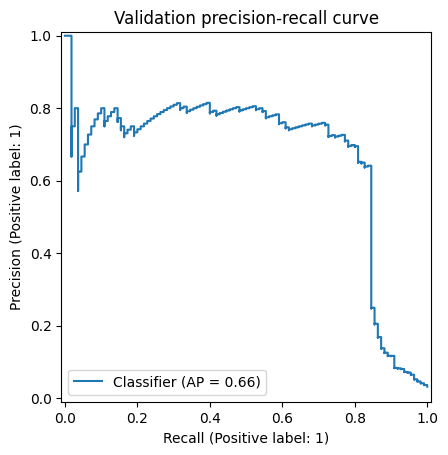

In [11]:
PrecisionRecallDisplay.from_predictions(
    valid["is_fraud"],
    valid_score,
)
plt.title("Validation precision-recall curve")
plt.show()

## Threshold by review capacity

Предположим, команда может дополнительно проверять около 5% validation-событий. Выбираем 95-й процентиль score как порог.

In [12]:
threshold = float(np.quantile(valid_score, 0.95))
print("Selected threshold:", round(threshold, 4))

Selected threshold: 0.6885


In [13]:
def metric_row(y_true, score, threshold):
    prediction = (score >= threshold).astype(int)
    return {
        "PR-AUC": average_precision_score(y_true, score),
        "ROC-AUC": roc_auc_score(y_true, score),
        "Precision": precision_score(
            y_true, prediction, zero_division=0
        ),
        "Recall": recall_score(y_true, prediction),
        "F1": f1_score(y_true, prediction),
        "Alert rate": prediction.mean(),
        "TP": confusion_matrix(y_true, prediction)[1, 1],
        "FP": confusion_matrix(y_true, prediction)[0, 1],
        "FN": confusion_matrix(y_true, prediction)[1, 0],
        "TN": confusion_matrix(y_true, prediction)[0, 0],
    }

test_score = model.predict_proba(test[feature_columns])[:, 1]

results = pd.DataFrame(
    {
        "validation": metric_row(
            valid["is_fraud"], valid_score, threshold
        ),
        "test": metric_row(
            test["is_fraud"], test_score, threshold
        ),
    }
).T

results.round(4)

,PR-AUC,ROC-AUC,Precision,Recall,F1,Alert rate,TP,FP,FN,TN
validation,0.6642,0.9386,0.5345,0.8455,0.6549,0.0500,93.0,81.0,17.0,3286.0
test,0.7260,0.9417,0.5567,0.8526,0.6736,0.0621,162.0,129.0,28.0,4366.0


## Inspect high-risk events

Так можно посмотреть, какие события модель отправила бы на ручную проверку.

In [14]:
review_queue = test[
    [
        "event_time",
        "user_id",
        "ip_id",
        "device_id",
        "country",
        "auth_method",
        "is_fraud",
        "seen_device_before",
        "seen_ip_before",
        "ip_unique_users_1h",
        "device_unique_users_24h",
    ]
].copy()
review_queue["fraud_score"] = test_score

review_queue.sort_values(
    "fraud_score", ascending=False
).head(15)

,event_time,user_id,ip_id,device_id,country,auth_method,is_fraud,seen_device_before,seen_ip_before,ip_unique_users_1h,device_unique_users_24h,fraud_score
15125,2025-03-15 04:14:47.780363129,u_0358,attacker_ip_023,attacker_dev_029,NL,password,1,0,0,9,17,0.999998
15123,2025-03-15 04:11:42.780363129,u_0197,attacker_ip_023,attacker_dev_029,NL,password,1,0,0,8,16,0.999998
15122,2025-03-15 04:11:05.780363129,u_0414,attacker_ip_023,attacker_dev_029,NL,password,1,0,0,7,15,0.999996
15121,2025-03-15 04:07:41.780363129,u_0016,attacker_ip_023,attacker_dev_029,NL,password,1,0,0,6,14,0.999992
15126,2025-03-15 04:15:14.780363129,u_0366,attacker_ip_023,attacker_dev_029,NL,password,1,1,0,10,18,0.999990
15117,2025-03-15 03:57:49.780363129,u_0498,attacker_ip_023,attacker_dev_029,NL,password,1,0,0,4,12,0.999988
15116,2025-03-15 03:52:30.780363129,u_0441,attacker_ip_023,attacker_dev_029,NL,password,1,0,0,3,11,0.999981
15120,2025-03-15 04:06:40.780363129,u_0162,attacker_ip_023,attacker_dev_029,NL,sms,1,0,0,5,13,0.999963
15113,2025-03-15 03:44:37.780363129,u_0333,attacker_ip_023,attacker_dev_029,NL,password,1,0,0,1,9,0.999941
16349,2025-03-21 09:11:54.606484545,u_0428,attacker_ip_028,attacker_dev_031,US,password,1,0,0,11,11,0.999918


## Takeaways

- Одна строка модельной таблицы соответствует одному логину.
- История пересчитывается относительно времени каждой строки.
- Текущий event добавляется в историю после вычисления признаков.
- Train, validation и test идут последовательно во времени.
- `PR-AUC` оценивает качество ранжирования при редком положительном классе.
- Порог — бизнес-решение: он определяет объем алертов и компромисс precision/recall.

Следующий разумный шаг — заменить логистическую регрессию на CatBoost или LightGBM, сохранив тот же temporal split и тот же test.